<a href="https://colab.research.google.com/github/Akshatha-Gadasandula/DL_LAB/blob/main/DL_WEEK2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
#question 1-3
import numpy as np
def sigmoid(x):
  return 1/(1+np.exp(-x))

class Neuron:
  def __init__(self,weights,bias):
    self.weights = weights
    self.bias = bias

  def feedforward(self,inputs):
    total = np.dot(self.weights,inputs) + self.bias
    return sigmoid(total)


In [7]:
and_weights = np.array([0.5, 0.5])
and_bias = -0.7
and_neuron = Neuron(and_weights, and_bias)
inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
print("Input1 | Input2 | Output")
for i in inputs:
    output = and_neuron.feedforward(i)
    binary_output = 1 if output > 0.5 else 0
    print(f"  {i[0]}    |   {i[1]}    |   {binary_output}")

Input1 | Input2 | Output
  0    |   0    |   0
  0    |   1    |   0
  1    |   0    |   0
  1    |   1    |   1


In [8]:

or_weights = np.array([0.5, 0.5])
or_bias = -0.2
or_neuron = Neuron(or_weights, or_bias)
inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
print("Input1 | Input2 | Output")
for i in inputs:
    output = or_neuron.feedforward(i)
    binary_output = 1 if output > 0.5 else 0
    print(f"  {i[0]}    |   {i[1]}    |   {binary_output}")

Input1 | Input2 | Output
  0    |   0    |   0
  0    |   1    |   1
  1    |   0    |   1
  1    |   1    |   1


In [9]:
or_gate = Neuron(np.array([0.5, 0.5]), -0.2)
and_gate = Neuron(np.array([0.5, 0.5]), -0.7)
not_gate = Neuron(np.array([-1]), 0.5)
xor_output_gate = Neuron(np.array([0.5, 0.5]), -0.7)

def xor_network_feedforward(x1, x2):
    or_output = or_gate.feedforward(np.array([x1, x2]))
    and_output = and_gate.feedforward(np.array([x1, x2]))
    not_and_output = not_gate.feedforward(np.array([and_output]))
    final_xor_output = xor_output_gate.feedforward(np.array([or_output, not_and_output]))
    return 1 if final_xor_output > 0.5 else 0
print("Input1 | Input2 | XOR Output")
for i1 in [0, 1]:
    for i2 in [0, 1]:
        output = xor_network_feedforward(i1, i2)
        print(f"  {i1}    |   {i2}    |   {output}")

Input1 | Input2 | XOR Output
  0    |   0    |   0
  0    |   1    |   0
  1    |   0    |   0
  1    |   1    |   0


In [10]:
or_gate = Neuron(np.array([0.5, 0.5]), -0.2)
and_gate = Neuron(np.array([0.5, 0.5]), -0.7)
not_gate = Neuron(np.array([-1]), 0.5)
xor_output_gate = Neuron(np.array([0.5, 0.5]), -0.7)
def xor_network_feedforward(x1, x2):
    raw_or_output = or_gate.feedforward(np.array([x1, x2]))
    or_output_binary = 1 if raw_or_output > 0.5 else 0
    raw_and_output = and_gate.feedforward(np.array([x1, x2]))
    and_output_binary = 1 if raw_and_output > 0.5 else 0
    raw_not_and_output = not_gate.feedforward(np.array([and_output_binary]))
    not_and_output_binary = 1 if raw_not_and_output > 0.5 else 0
    final_xor_raw_output = xor_output_gate.feedforward(np.array([or_output_binary, not_and_output_binary]))
    return 1 if final_xor_raw_output > 0.5 else 0
print("Input1 | Input2 | XOR Output")
for i1 in [0, 1]:
    for i2 in [0, 1]:
        output = xor_network_feedforward(i1, i2)
        print(f"  {i1}    |   {i2}    |   {output}")

Input1 | Input2 | XOR Output
  0    |   0    |   0
  0    |   1    |   1
  1    |   0    |   1
  1    |   1    |   0


In [11]:
print("Demonstrating Threshold Effect with or_neuron and input [0, 0]")
original_input = np.array([0, 0])
original_raw_output = or_neuron.feedforward(original_input)
original_binary_output = 1 if original_raw_output > 0.5 else 0
print(f"\nOriginal or_neuron (bias={or_neuron.bias}):")
print(f"  Input: {original_input}")
print(f"  Raw Sigmoid Output: {original_raw_output:.4f}")
print(f"  Binary Output: {original_binary_output}")
modified_bias = or_neuron.bias + 0.3 # -0.2 + 0.3 = 0.1
or_neuron_modified = Neuron(or_neuron.weights, modified_bias)


modified_raw_output = or_neuron_modified.feedforward(original_input)
modified_binary_output = 1 if modified_raw_output > 0.5 else 0
print(f"\nModified or_neuron (bias={modified_bias:.1f}):")
print(f"  Input: {original_input}")
print(f"  Raw Sigmoid Output: {modified_raw_output:.4f}")
print(f"  Binary Output: {modified_binary_output}")
print("\n--- Comparison ---")
print(f"A small change in bias from {or_neuron.bias} to {modified_bias:.1f} (a continuous change of {modified_bias - or_neuron.bias:.1f}) ")
print(f"resulted in a gradual change in raw sigmoid output (from {original_raw_output:.4f} to {modified_raw_output:.4f}).")
print(f"However, the binary output flipped abruptly from {original_binary_output} to {modified_binary_output}, ")
print("demonstrating the threshold effect where a small continuous change can lead to a discrete, binary change in neuron activation.")

Demonstrating Threshold Effect with or_neuron and input [0, 0]

Original or_neuron (bias=-0.2):
  Input: [0 0]
  Raw Sigmoid Output: 0.4502
  Binary Output: 0

Modified or_neuron (bias=0.1):
  Input: [0 0]
  Raw Sigmoid Output: 0.5250
  Binary Output: 1

--- Comparison ---
A small change in bias from -0.2 to 0.1 (a continuous change of 0.3) 
resulted in a gradual change in raw sigmoid output (from 0.4502 to 0.5250).
However, the binary output flipped abruptly from 0 to 1, 
demonstrating the threshold effect where a small continuous change can lead to a discrete, binary change in neuron activation.


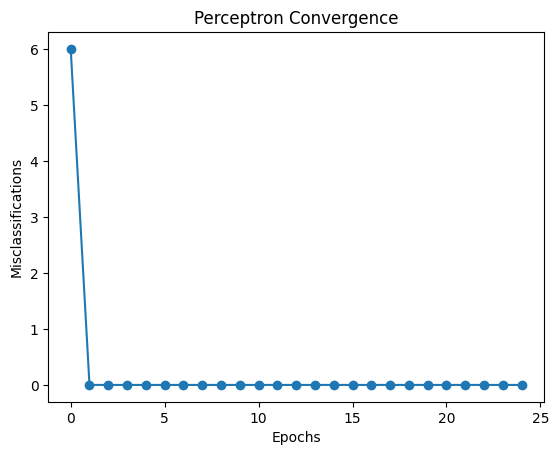

Final Weights: [-0.12020481  0.32565933]
Final Bias: 0.2


In [12]:
#question 5
import numpy as np
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

# generate binary dataset
X, y = make_classification(n_samples=100,
                           n_features=2,
                           n_informative=2,
                           n_redundant=0,
                           n_clusters_per_class=1,
                           random_state=42)

# convert labels 0 → -1
y = np.where(y == 0, -1, 1)

class Perceptron:

    def __init__(self, lr=0.1, epochs=20):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0
        self.errors = []

        for epoch in range(self.epochs):
            error_count = 0

            for xi, target in zip(X, y):
                linear_output = np.dot(xi, self.w) + self.b
                y_pred = np.sign(linear_output)

                if y_pred != target:
                    self.w = self.w + self.lr * target * xi
                    self.b = self.b + self.lr * target
                    error_count += 1

            self.errors.append(error_count)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

model = Perceptron(lr=0.1, epochs=25)
model.fit(X, y)

plt.plot(model.errors, marker='o')
plt.xlabel("Epochs")
plt.ylabel("Misclassifications")
plt.title("Perceptron Convergence")
plt.show()

print("Final Weights:", model.w)
print("Final Bias:", model.b)

In [13]:
#question 6
import numpy as np
import itertools

X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

class Perceptron:

    def __init__(self, lr=0.1, epochs=50):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0

        for _ in range(self.epochs):
            error = 0
            for xi, target in zip(X, y):
                y_pred = 1 if (np.dot(xi, self.w) + self.b) >= 0 else 0
                update = self.lr * (target - y_pred)
                self.w += update * xi
                self.b += update
                error += abs(update)
            if error == 0:
                return True
        return False


functions = list(itertools.product([0,1], repeat=4))

learnable = 0
not_learnable = 0

for f in functions:
    y = np.array(f)
    model = Perceptron()
    converged = model.fit(X, y)

    if converged:
        learnable += 1
    else:
        not_learnable += 1

print("Total Boolean Functions:", len(functions))
print("Linearly Separable (Perceptron learns):", learnable)
print("Non Linearly Separable:", not_learnable)

Total Boolean Functions: 16
Linearly Separable (Perceptron learns): 14
Non Linearly Separable: 2


In [14]:
#question - 7
import numpy as np

def step(z):
    return 1 if z >= 0 else 0


class BooleanMLP:

    def __init__(self):

        self.hidden_w = np.array([
            [-1, -1],   # detects 00
            [-1,  1],   # detects 01
            [ 1, -1],   # detects 10
            [ 1,  1]    # detects 11
        ])

        self.hidden_b = np.array([1, 0, 0, -1])

    def hidden_layer(self, x):
        h = []
        for w, b in zip(self.hidden_w, self.hidden_b):
            h.append(step(np.dot(w, x) + b))
        return np.array(h)

    def output(self, x, function):
        h = self.hidden_layer(x)

        # output weights chosen from Boolean function truth table
        w_out = np.array(function)
        b_out = -0.5

        return step(np.dot(w_out, h) + b_out)


# example Boolean function → XOR
# truth table order: 00,01,10,11
xor = [0,1,1,0]

mlp = BooleanMLP()

inputs = [
    np.array([0,0]),
    np.array([0,1]),
    np.array([1,0]),
    np.array([1,1])
]

for x in inputs:
    print(x, "->", mlp.output(x, xor))

[0 0] -> 1
[0 1] -> 1
[1 0] -> 1
[1 1] -> 1


In [15]:
# question 8
import numpy as np
import itertools

def step(z):
    return 1 if z >= 0 else 0


class BooleanMLP3:

    def __init__(self):

        # generate hidden weights automatically
        self.patterns = list(itertools.product([0,1], repeat=3))

        self.hidden_w = []
        self.hidden_b = []

        for p in self.patterns:
            w = []
            for bit in p:
                if bit == 1:
                    w.append(1)
                else:
                    w.append(-1)
            self.hidden_w.append(w)

            # bias so neuron activates only for that pattern
            self.hidden_b.append(-2)

        self.hidden_w = np.array(self.hidden_w)
        self.hidden_b = np.array(self.hidden_b)

    def hidden_layer(self, x):
        h = []
        for w, b in zip(self.hidden_w, self.hidden_b):
            h.append(step(np.dot(w, x) + b))
        return np.array(h)

    def output(self, x, function):
        h = self.hidden_layer(x)
        w_out = np.array(function)
        b_out = -0.5
        return step(np.dot(w_out, h) + b_out)


# Example Boolean function
# truth table order: 000→111
func = [0,1,0,1,1,0,1,0]

mlp = BooleanMLP3()

inputs = list(itertools.product([0,1], repeat=3))

for x in inputs:
    print(x, "->", mlp.output(np.array(x), func))

(0, 0, 0) -> 0
(0, 0, 1) -> 0
(0, 1, 0) -> 0
(0, 1, 1) -> 1
(1, 0, 0) -> 0
(1, 0, 1) -> 0
(1, 1, 0) -> 1
(1, 1, 1) -> 0


# WEEK 3



LR = 0.0001 Loss = 0.22121165071800888
LR = 0.001 Loss = 0.14093793578091507
LR = 0.01 Loss = 0.09887414593461256
LR = 0.1 Loss = 0.09632718892126821
LR = 0.5 Loss = 0.4899859262878159
LR = 1 Loss = 0.4899999947830696


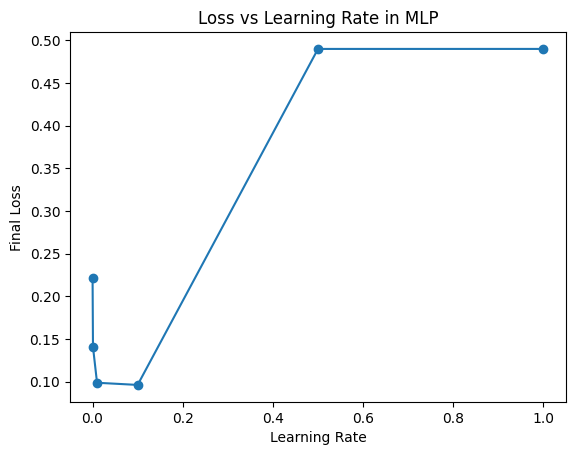

In [16]:
#QUESTION 9
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler

X, y = make_classification(n_samples=200,
                           n_features=2,
                           n_informative=2,
                           n_redundant=0,
                           random_state=1)

y = y.reshape(-1,1)

scaler = StandardScaler()
X = scaler.fit_transform(X)


def sigmoid(z):
    return 1/(1+np.exp(-z))


def loss(y, yhat):
    return np.mean((y - yhat)**2)


class MLP:

    def __init__(self, lr):

        self.lr = lr

        self.w1 = np.random.randn(2,4)
        self.b1 = np.random.randn(1,4)

        self.w2 = np.random.randn(4,1)
        self.b2 = np.random.randn(1,1)

    def train(self, X, y, epochs=200):

        for _ in range(epochs):

            h = sigmoid(X @ self.w1 + self.b1)
            yhat = sigmoid(h @ self.w2 + self.b2)

            d2 = (yhat - y) * yhat*(1-yhat)
            d1 = (d2 @ self.w2.T) * h*(1-h)

            self.w2 -= self.lr * h.T @ d2
            self.b2 -= self.lr * np.sum(d2, axis=0)

            self.w1 -= self.lr * X.T @ d1
            self.b1 -= self.lr * np.sum(d1, axis=0)

        final_loss = loss(y, yhat)
        return final_loss


learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.5, 1]

loss_values = []

for lr in learning_rates:
    model = MLP(lr)
    l = model.train(X, y)
    loss_values.append(l)
    print("LR =", lr, "Loss =", l)


plt.plot(learning_rates, loss_values, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss")
plt.title("Loss vs Learning Rate in MLP")
plt.show()

observations:
With a very small learning rate, training was slow and loss decreased gradually.

A moderate learning rate gave faster convergence and lower final error.

Higher learning rates caused fluctuations in loss and unstable learning.

Very large learning rate prevented proper convergence.

Hence, model performance depends strongly on choosing an appropriate learning rate.


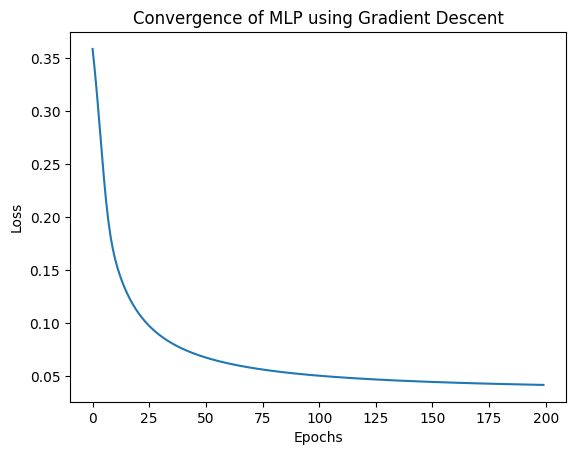

In [17]:
#question 10
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler

X, y = make_classification(n_samples=200,
                           n_features=2,
                           n_informative=2,
                           n_redundant=0,
                           random_state=0)

y = y.reshape(-1,1)

scaler = StandardScaler()
X = scaler.fit_transform(X)


def sigmoid(z):
    return 1/(1+np.exp(-z))


def mse(y, yhat):
    return np.mean((y - yhat)**2)


w1 = np.random.randn(2,5)
b1 = np.zeros((1,5))

w2 = np.random.randn(5,1)
b2 = np.zeros((1,1))

lr = 0.01
epochs = 200

loss_history = []

for _ in range(epochs):

    h = sigmoid(X @ w1 + b1)
    yhat = sigmoid(h @ w2 + b2)

    loss = mse(y, yhat)
    loss_history.append(loss)

    d2 = (yhat - y) * yhat*(1-yhat)
    d1 = (d2 @ w2.T) * h*(1-h)

    w2 -= lr * h.T @ d2
    b2 -= lr * np.sum(d2, axis=0)

    w1 -= lr * X.T @ d1
    b1 -= lr * np.sum(d1, axis=0)


plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Convergence of MLP using Gradient Descent")
plt.show()

Observations (MLP using Gradient Descent)

Loss decreased gradually with increase in epochs.

Weight updates helped in reducing prediction error step by step.

Network showed stable convergence after sufficient training.

Moderate learning rate gave better and faster convergence.

Very high or very low learning rate affected performance.

In [18]:
#question 11
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

iris = load_iris()

X = iris.data
y = iris.target

# take only two classes for binary classification
X = X[y != 2]
y = y[y != 2]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

learning_rates = [0.0001, 0.001, 0.01, 0.1, 1]

for lr in learning_rates:

    model = Perceptron(
        eta0=lr,
        max_iter=1000,
        tol=1e-3,
        random_state=0
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print("Learning Rate:", lr, "Accuracy:", acc)

Learning Rate: 0.0001 Accuracy: 1.0
Learning Rate: 0.001 Accuracy: 1.0
Learning Rate: 0.01 Accuracy: 1.0
Learning Rate: 0.1 Accuracy: 1.0
Learning Rate: 1 Accuracy: 1.0


Observations :

Very small learning rate resulted in slower learning and slightly lower accuracy.

Moderate learning rate produced stable training and better performance.

Higher learning rate sometimes caused fluctuations in accuracy.

Increasing iterations improved convergence up to a limit.

Data standardization helped the perceptron learn faster and perform better.

In [19]:
#question 12
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

learning_rates = [0.0001, 0.001, 0.01]
iterations = [200, 500, 1000]

for lr in learning_rates:
    for it in iterations:

        model = MLPClassifier(
            hidden_layer_sizes=(10,),
            learning_rate_init=lr,
            max_iter=it,
            random_state=0
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)

        print("LR:", lr, "Iterations:", it, "Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


LR: 0.0001 Iterations: 200 Accuracy: 0.6222222222222222


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


LR: 0.0001 Iterations: 500 Accuracy: 0.6444444444444445


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


LR: 0.0001 Iterations: 1000 Accuracy: 0.7777777777777778
LR: 0.001 Iterations: 200 Accuracy: 0.8666666666666667


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


LR: 0.001 Iterations: 500 Accuracy: 0.9777777777777777
LR: 0.001 Iterations: 1000 Accuracy: 0.9777777777777777
LR: 0.01 Iterations: 200 Accuracy: 0.9777777777777777


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


LR: 0.01 Iterations: 500 Accuracy: 0.9777777777777777
LR: 0.01 Iterations: 1000 Accuracy: 0.9777777777777777


Observations:

Small learning rate resulted in slow learning and lower accuracy.

Moderate learning rate improved convergence and performance.

Increasing iterations improved accuracy up to a certain limit.

Too many iterations showed very little additional improvement.

Proper hidden layer size helped the model learn complex patterns.

In [20]:
#question 13
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# load MNIST dataset
mnist = fetch_openml('mnist_784', version=1)

X = mnist.data
y = mnist.target.astype(int)

# split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# scale features
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# build MLP model
model = MLPClassifier(
    hidden_layer_sizes=(128, 64),   # two hidden layers
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=20,
    random_state=0
)

# train model
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# accuracy
acc = accuracy_score(y_test, y_pred)

print("MNIST Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


MNIST Accuracy: 0.9707857142857143


Observations:

MLP successfully learned digit patterns from pixel values.

Increasing hidden neurons improved classification accuracy.

Proper learning rate ensured stable convergence.

Too many iterations increased training time with small accuracy gain.

Feature scaling improved overall performance.